# **"1. Importing Libraries & Modules"**


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import accuracy_score
import yfinance as yf
from keras.models import Sequential
from keras.layers import LSTM, Dense

# **"2. Data Collecting"**

In [4]:
stock = 'AAPL'  # Apple Stock Ticker
start_date = '2015-01-01'
end_date = '2024-01-01'
df = yf.download(stock, start=start_date, end=end_date)

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


# **"3. Data Preprocessing"**






# > 3.1 (Removing other parameters except Close price)



In [5]:
data = df['Close'].values.reshape(-1, 1)
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)



# > 3.2 (Splitting data into 80% = Training and 20% = Test)



In [6]:
train_size = int(len(data_scaled) * 0.8)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]



# > 3.3 (function to create sequence (loop/epochs) for LSTM)



In [7]:
def create_dataset(data, time_step=100):
    X, Y = [], []
    for i in range(len(data) - time_step - 1):
        X.append(data[i:(i + time_step), 0])
        Y.append(data[i + time_step, 0])
    return np.array(X), np.array(Y)

time_step = 100
X_train, Y_train = create_dataset(train_data, time_step)
X_test, Y_test = create_dataset(test_data, time_step)



# > 3.4 (Reshaping for LSTM)



In [8]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)


# **"4. Building LSTM Model with MSE"**




In [ ]:
# while training we are using LSTM model in both the only difference is
# one has loss function = MSE and another has loss function = MAE
lstm_model = Sequential()
lstm_model.add(LSTM(units=50, return_sequences=True, input_shape=(time_step, 1)))
lstm_model.add(LSTM(units=50, return_sequences=False))
lstm_model.add(Dense(units=25, activation='relu'))
lstm_model.add(Dense(units=1))
#using the loss = MSE
lstm_model.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


# **"5. Training MSE Model"**




In [10]:
lstm_model.fit(X_train, Y_train, epochs=50, batch_size=32, validation_data=(X_test, Y_test), verbose=1)

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - loss: 0.0331 - val_loss: 0.0022
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 4.5839e-04 - val_loss: 0.0021
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 4.4109e-04 - val_loss: 0.0023
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 4.1438e-04 - val_loss: 0.0014
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 3.9073e-04 - val_loss: 0.0014
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 3.2577e-04 - val_loss: 0.0016
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 4.3904e-04 - val_loss: 0.0014
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 3.4816e-04 - val_loss: 0.0011
Epoch 9/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 2.7930e-04 - val_loss: 0.0024
Epoch 10/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 3.4974e-04 - val_loss: 0.0021
Epoch 11/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 3.9024e-04 - val_loss: 0.0011
Epoch 12/50
54/54 ━━━━━

# **"6. Building MAE Model"**




In [11]:
mae_model = Sequential()
mae_model.add(LSTM(units=50, return_sequences=True, input_shape=(time_step, 1)))
mae_model.add(LSTM(units=50, return_sequences=False))
mae_model.add(Dense(units=25, activation='relu'))
mae_model.add(Dense(units=1))
# using the loss = MAE
mae_model.compile(optimizer='adam', loss='mean_absolute_error')

# **"7. Training MAE Model"**




In [3]:
mae_model.fit(X_train, Y_train, epochs=50, batch_size=32, validation_data=(X_test, Y_test), verbose=1)

NameError: name 'mae_model' is not defined

In [ ]:
# Saving the trained LSTM model in .keras format
lstm_model.save('lstm_model.keras')

# Saving the trained MAE model in .keras format
mae_model.save('mae_model.keras')

# Optionally, save the scaler (if needed later for preprocessing)
import pickle
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)


# **"8. Making the predictions"**




In [13]:
# lstm model prediction
lstm_predictions = lstm_model.predict(X_test)
lstm_predictions = scaler.inverse_transform(lstm_predictions.reshape(-1, 1))
# mae model prediction
mae_predictions = mae_model.predict(X_test)
mae_predictions = scaler.inverse_transform(mae_predictions.reshape(-1, 1))

Y_test_actual = scaler.inverse_transform(Y_test.reshape(-1, 1))

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step  
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step  


# **"9. Visualizing (Comparisons)"**




In [14]:
# Visualization (Comparisons)
plt.figure(figsize=(40, 20))

<Figure size 4000x2000 with 0 Axes>

<Figure size 4000x2000 with 0 Axes>



# > 9.1 (LSTM Prediction vs Actual Price)



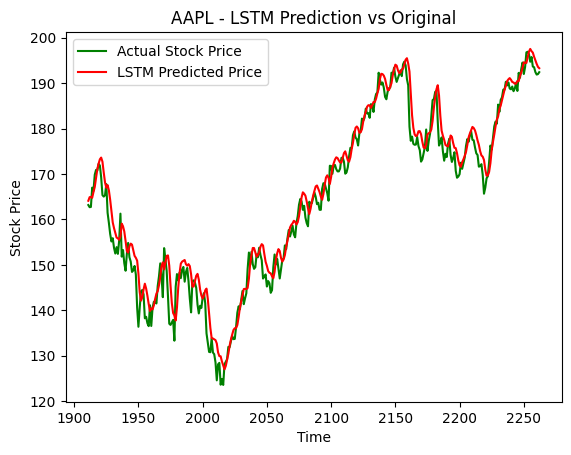

In [15]:
plt.plot(range(train_size + time_step, train_size + time_step + len(Y_test_actual)),
         Y_test_actual, color='green', label='Actual Stock Price')
plt.plot(range(train_size + time_step, train_size + time_step + len(lstm_predictions)),
         lstm_predictions, color='red', label='LSTM Predicted Price')
plt.title(f'{stock} - LSTM Prediction vs Original')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()



# > 9.2 (MAE Model Prediction vs Actual Price)



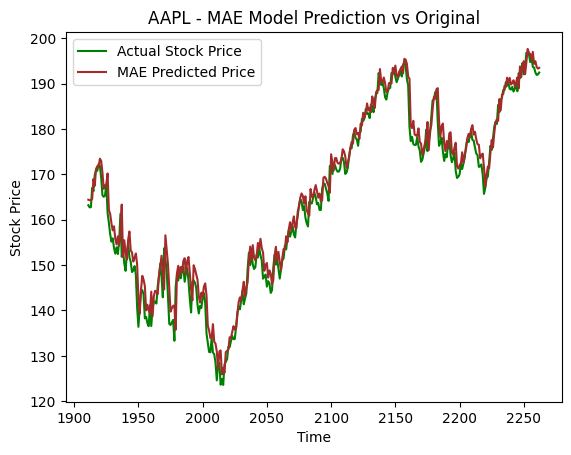

In [16]:
# MAE Model Prediction vs Actual Price
plt.plot(range(train_size + time_step, train_size + time_step + len(Y_test_actual)),
         Y_test_actual, color='green', label='Actual Stock Price')
plt.plot(range(train_size + time_step, train_size + time_step + len(mae_predictions)),
         mae_predictions, color='brown', label='MAE Predicted Price')
plt.title(f'{stock} - MAE Model Prediction vs Original')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()



# > 9.3 (LSTM Model Prediction vs MAE Model Prediction)



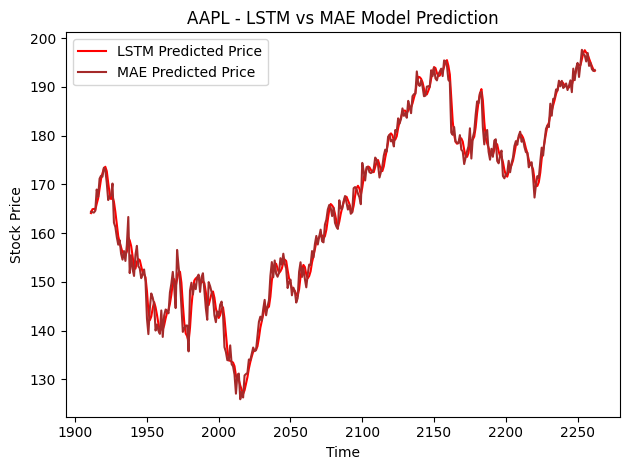

In [17]:
# 3. LSTM vs MAE Model Prediction
plt.plot(range(train_size + time_step, train_size + time_step + len(lstm_predictions)),
         lstm_predictions, color='red', label='LSTM Predicted Price')
plt.plot(range(train_size + time_step, train_size + time_step + len(mae_predictions)),
         mae_predictions, color='brown', label='MAE Predicted Price')
plt.title(f'{stock} - LSTM vs MAE Model Prediction')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()

plt.tight_layout()
plt.show()

# **"10. Evaluating Metrics "**




In [18]:
lstm_mae = mean_absolute_error(Y_test_actual, lstm_predictions)
lstm_rmse = np.sqrt(mean_squared_error(Y_test_actual, lstm_predictions))
lstm_mape = np.mean(np.abs((Y_test_actual - lstm_predictions) / Y_test_actual)) * 100

mae_mae = mean_absolute_error(Y_test_actual, mae_predictions)
mae_rmse = np.sqrt(mean_squared_error(Y_test_actual, mae_predictions))
mae_mape = np.mean(np.abs((Y_test_actual - mae_predictions) / Y_test_actual)) * 100

print(f"LSTM Model - MAE: {lstm_mae}, RMSE: {lstm_rmse}, MAPE: {lstm_mape}%")
print(f"MAE Model - MAE: {mae_mae}, RMSE: {mae_rmse}, MAPE: {mae_mape}%")

LSTM Model - MAE: 2.7311352816495025, RMSE: 3.617109659451157, MAPE: 1.7398613073641231%
MAE Model - MAE: 2.4076228141784664, RMSE: 3.107465416042498, MAPE: 1.5314984522613169%


# **"11. Accuracy Comparision"**




In [22]:
from sklearn.metrics import r2_score, explained_variance_score
lstm_accuracy = 100 - lstm_mape
mae_accuracy = 100 - mae_mape

lstm_r2 = r2_score(Y_test_actual, lstm_predictions)
mae_r2 = r2_score(Y_test_actual, mae_predictions)

lstm_evs = explained_variance_score(Y_test_actual, lstm_predictions)
mae_evs = explained_variance_score(Y_test_actual, mae_predictions)

print(f"LSTM Model Accuracy: {lstm_accuracy:.2f}%")
print(f"LSTM Model R-squared: {lstm_r2:.2f}")
print(f"LSTM Model Explained Variance Score: {lstm_evs:.2f}")

print(f"MAE Model Accuracy: {mae_accuracy:.2f}%")
print(f"MAE Model R-squared: {mae_r2:.2f}")
print(f"MAE Model Explained Variance Score: {mae_evs:.2f}")

LSTM Model Accuracy: 98.26%
LSTM Model R-squared: 0.96
LSTM Model Explained Variance Score: 0.97
MAE Model Accuracy: 98.47%
MAE Model R-squared: 0.97
MAE Model Explained Variance Score: 0.98
